In [2]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [3]:
import os, sys
sys.path.append("..")

import torch
import wandb
from tqdm import tqdm

from src.light_gcot import LightGCOT
from src.distributions import StandardNormalSampler, SwissRollSampler

In [4]:
torch.set_default_tensor_type(torch.DoubleTensor)

/Users/michael/miniconda3/envs/light-gcot/lib/python3.12/site-packages/torch/__init__.py:690: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_52h9q6gsr9/croot/pytorch-select_1707258249748/work/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)


## 2. Config

In [5]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
# assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 500
M_POTENTIALS = 2
INIT_BY_SAMPLES = False
A_DIAGONAL_INIT = 0.1
IS_B_DIAGONAL = True

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

EPSILON = 0.002

D_LR = 3e-4 # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_GRADIENT_MAX_NORM = float('inf')

PLOT_EVERY = 500
MAX_STEPS = 20000
CONTINUE = -1

In [6]:
torch.manual_seed(OUTPUT_SEED); np.random.seed(OUTPUT_SEED)

EPS = EPSILON

In [7]:
EXP_NAME = f'LightGCOT_Swiss_Roll_EPSILON_{EPSILON}_M_{M_POTENTIALS}'
OUTPUT_PATH = '../checkpoints/{}'.format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR=D_LR,
    BATCH_SIZE=BATCH_SIZE,
    EPSILON=EPSILON,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    INIT_BY_SAMPLES=INIT_BY_SAMPLES,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
    IS_B_DIAGONAL=IS_B_DIAGONAL,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create samplers

In [8]:
X_sampler = StandardNormalSampler(dim=X_DIM, device="cpu")
Y_sampler = SwissRollSampler(dim=Y_DIM, device="cpu")

## 4. Model initialization

In [9]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    is_B_diagonal=IS_B_DIAGONAL,
)

if INIT_BY_SAMPLES:
    D.init_a_by_samples(Y_sampler.sample(N_POTENTIALS))

D_opt = torch.optim.Adam(D.parameters(), lr=D_LR)

if CONTINUE > -1:
    D_opt.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_{OUTPUT_SEED}_{CONTINUE}.pt")))

In [10]:
for step in range(CONTINUE + 1, MAX_STEPS):
    # training cycle
    D_opt.zero_grad()

    X, Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)

    f_c = D.compute_dual_potential(X)
    f = D.compute_primal_potential(Y)

    D_loss = -(f_c + f).mean()
    D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    print(
        f"{step}: D gradient norm: {D_gradient_norm.item():.4f} D_loss: {D_loss.item():.4f} lam_min(A): {torch.min(D.A_diagonal_matrix)}, lam_min(B): {torch.min(D.B_m)}"
    )

0: D gradient norm: 0.0018 D_loss: -0.0005 lam_min(A): 0.09970002131222684, lam_min(B): 1.0
1: D gradient norm: 0.0070 D_loss: -0.0013 lam_min(A): 0.09939964935398551, lam_min(B): 1.0
2: D gradient norm: 0.0021 D_loss: -0.0010 lam_min(A): 0.09909888093957947, lam_min(B): 1.0
3: D gradient norm: 0.0012 D_loss: -0.0004 lam_min(A): 0.09879840850857102, lam_min(B): 1.0
4: D gradient norm: 0.0016 D_loss: -0.0006 lam_min(A): 0.09849653344889873, lam_min(B): 1.0
5: D gradient norm: 0.0011 D_loss: -0.0004 lam_min(A): 0.09820698176554962, lam_min(B): 1.0
6: D gradient norm: 0.0015 D_loss: -0.0006 lam_min(A): 0.09790478907298096, lam_min(B): 1.0
7: D gradient norm: 0.0028 D_loss: -0.0012 lam_min(A): 0.09760139027701711, lam_min(B): 1.0
8: D gradient norm: 0.0028 D_loss: -0.0007 lam_min(A): 0.09730802241322009, lam_min(B): 1.0
9: D gradient norm: 0.0019 D_loss: -0.0007 lam_min(A): 0.09701161373970735, lam_min(B): 1.0
10: D gradient norm: 0.0012 D_loss: -0.0006 lam_min(A): 0.09671166661569422, lam

In [ ]:
torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt.pt"))

In [18]:
from matplotlib import pyplot as plt

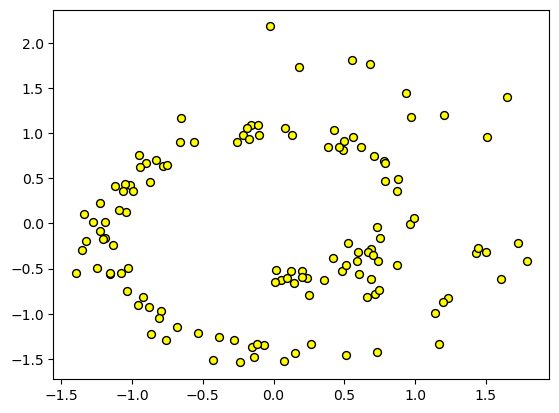

In [20]:
y_pred = D(X)
    
plt.scatter(y_pred[:, 0], y_pred[:, 1], 
            c="yellow", s=32, edgecolors="black", label = "Fitted distribution", zorder=1)

(array([[  9.,  34.,  80., 151.,  61.,  12.,  23.,  37.,  17.,  76.],
        [ 30.,  19.,  53., 147.,  60.,  26.,  25.,  54.,  20.,  66.]]),
 array([0.31276779, 0.83169052, 1.35061325, 1.86953599, 2.38845872,
        2.90738145, 3.42630419, 3.94522692, 4.46414966, 4.98307239,
        5.50199512]),
 <a list of 2 BarContainer objects>)

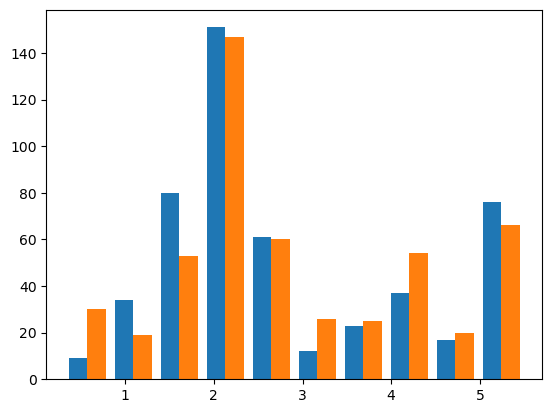

In [22]:
plt.hist(D.A_diagonal_matrix.detach().numpy())

(array([[  0.,   3.,   8.,  10., 153., 229.,  77.,   8.,   6.,   6.],
        [ 11.,   6.,   0.,  96., 118., 165.,  90.,   0.,   1.,  13.]]),
 array([-5.09781315, -4.08495586, -3.07209857, -2.05924128, -1.04638399,
        -0.0335267 ,  0.97933059,  1.99218788,  3.00504517,  4.01790246,
         5.03075976]),
 <a list of 2 BarContainer objects>)

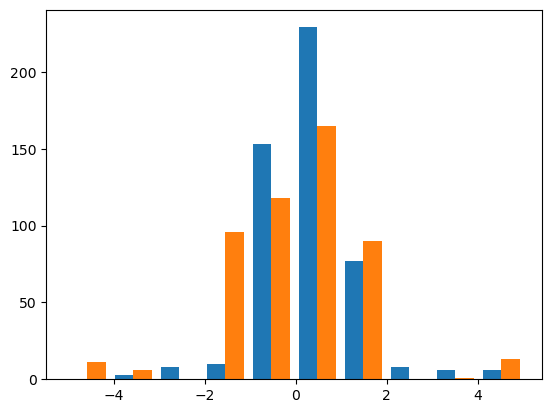

In [23]:
plt.hist(D.a.detach().numpy())

## 5. Model training

In [9]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    # training cycle
    D_opt.zero_grad()

    X, Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)

    f_c = D.compute_dual_potential(X)
    f = D.compute_primal_potential(Y)

    D_loss = -(f_c + f).mean()
    D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)
    wandb.log({f"D_loss": D_loss.item()}, step=step)

torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt.pt"))

wandb.finish()

wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


D gradient norm,nan
D_loss,nan


Problem at: /Users/michael/miniconda3/envs/light-sb/lib/python3.12/site-packages/wandb/sdk/wandb_init.py 854 getcaller


KeyboardInterrupt: 